# Setup | Version |  Package Imports

In [10]:
import os
import snapatac2 as snap
import anndata
import pandas as pd
import numpy as np
import scanpy as sc
import sys
import glob, os, re
from pathlib import Path
import resource

### Softcap | Hardcap | Memory Increase

In [11]:
soft, hard = resource.getrlimit(resource.RLIMIT_AS)
print(f"Before: soft = {soft//1024//1024} MiB, hard = {'unlimited' if hard == resource.RLIM_INFINITY else hard//1024//1024} MiB")

resource.setrlimit(resource.RLIMIT_AS, (hard, hard))

soft_after, hard_after = resource.getrlimit(resource.RLIMIT_AS)
print(f"After:  soft = {soft_after//1024//1024} MiB, hard = {'unlimited' if hard_after == resource.RLIM_INFINITY else hard_after//1024//1024} MiB")

Before: soft = 146484 MiB, hard = 292968 MiB
After:  soft = 292968 MiB, hard = 292968 MiB


### Garbace Collecting

In [12]:
import gc
gc.collect()

1044

### Project Root

In [13]:
PROJECT_ROOT = Path.cwd().parent    
DATA_DIR     = PROJECT_ROOT / "data"
RAW_DIR      = DATA_DIR / "raw_data"
OUTPUT_DIR   = PROJECT_ROOT / "output"
print("Working directory is now:", PROJECT_ROOT)

Working directory is now: /mnt/germain/work/tomohl/pgboost-project


# Fragment / Object Imports

## Cohort Definitions

In [14]:
import os
import glob

frag_paths = {}

# 1. Iterate through all subdirectories in the root_dir
for subdir in glob.glob(os.path.join(RAW_DIR, "*")):
    # 2. Check if the current item is a directory
    if os.path.isdir(subdir):
        # 3. Search for the fragment file within each subdirectory
        pattern = os.path.join(subdir, "*_atac_fragments.tsv.gz")
        frag_file = glob.glob(pattern)
        
        # 4. If a fragment file is found, add it to the dictionary
        if frag_file:
            # The key is the directory name (e.g., "GSM5818649")
            key = os.path.basename(subdir)
            frag_paths[key] = frag_file[0]

# Now, `frag_paths` will contain the full paths to the fragment files
# with the directory name as the key.


In [15]:
files = [(s, frag) for s, frag in frag_paths.items()]


## Fragment Import

In [16]:
%%time
 
out_dir = DATA_DIR / "fragment_files" / "fragments-1"
out_dir.mkdir(parents=True, exist_ok=True)

out_paths = [
    out_dir / f"{name}.h5ad"
    for name, _ in files
]


adatas = snap.pp.import_fragments(
    [fl for _, fl in files],
    file=[str(p) for p in out_paths],
    chrom_sizes=snap.genome.hg38,
    min_num_fragments=500,
    sorted_by_barcode = False,
    n_jobs = 12
)

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 34/34 [08:02<00:00, 14.18s/it]


CPU times: user 190 ms, sys: 59.8 ms, total: 250 ms
Wall time: 8min 2s


In [17]:
adatas

[AnnData object with n_obs x n_vars = 2709 x 0 backed at '/mnt/germain/work/tomohl/pgboost-project/data/fragment_files/fragments-1/GSM5818676.h5ad'
     obs: 'n_fragment', 'frac_dup', 'frac_mito'
     uns: 'reference_sequences'
     obsm: 'fragment_paired',
 AnnData object with n_obs x n_vars = 3924 x 0 backed at '/mnt/germain/work/tomohl/pgboost-project/data/fragment_files/fragments-1/GSM5818654.h5ad'
     obs: 'n_fragment', 'frac_dup', 'frac_mito'
     uns: 'reference_sequences'
     obsm: 'fragment_paired',
 AnnData object with n_obs x n_vars = 3442 x 0 backed at '/mnt/germain/work/tomohl/pgboost-project/data/fragment_files/fragments-1/GSM5818674.h5ad'
     obs: 'n_fragment', 'frac_dup', 'frac_mito'
     uns: 'reference_sequences'
     obsm: 'fragment_paired',
 AnnData object with n_obs x n_vars = 3030 x 0 backed at '/mnt/germain/work/tomohl/pgboost-project/data/fragment_files/fragments-1/GSM5818657.h5ad'
     obs: 'n_fragment', 'frac_dup', 'frac_mito'
     uns: 'reference_sequences

# Load Imported Fragments

In [9]:
out_dir = PROJECT_ROOT / "data" / "fragment_files" / "fragments-1"
out_dir.mkdir(parents=True, exist_ok=True)

out_paths = [
    out_dir / f"{name}.h5ad"
    for name, _ in files
]

adatas = [snap.read(str(p)) for p in out_paths]

thread '<unnamed>' panicked at /opt/conda/conda-bld/snapatac2_1736268329721/_build_env/.cargo/registry/src/index.crates.io-6f17d22bba15001f/pyanndata-0.4.1/src/anndata.rs:36:60:
called `Result::unwrap()` on an `Err` value: H5Fopen(): unable to open file: unable to open file: name = '/mnt/germain/work/tomohl/pgboost-project/data/fragment_files/fragments-1/GSM5818676.h5ad', errno = 2, error message = 'No such file or directory', flags = 1, o_flags = 2
note: run with `RUST_BACKTRACE=1` environment variable to display a backtrace


PanicException: called `Result::unwrap()` on an `Err` value: H5Fopen(): unable to open file: unable to open file: name = '/mnt/germain/work/tomohl/pgboost-project/data/fragment_files/fragments-1/GSM5818676.h5ad', errno = 2, error message = 'No such file or directory', flags = 1, o_flags = 2

# Metrics

In [18]:
%%time
snap.metrics.tsse(adatas, snap.genome.hg38)


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 34/34 [00:50<00:00,  1.50s/it]


CPU times: user 242 ms, sys: 60.1 ms, total: 302 ms
Wall time: 51.5 s


## TSSE Test Plot

In [19]:
adata_map = {
    name: adata
    for (name, _), adata in zip(files, adatas)
}

adata_map



{'GSM5818676': AnnData object with n_obs x n_vars = 2709 x 0 backed at '/mnt/germain/work/tomohl/pgboost-project/data/fragment_files/fragments-1/GSM5818676.h5ad'
     obs: 'n_fragment', 'frac_dup', 'frac_mito', 'tsse'
     uns: 'reference_sequences', 'library_tsse', 'TSS_profile', 'frac_overlap_TSS'
     obsm: 'fragment_paired',
 'GSM5818654': AnnData object with n_obs x n_vars = 3924 x 0 backed at '/mnt/germain/work/tomohl/pgboost-project/data/fragment_files/fragments-1/GSM5818654.h5ad'
     obs: 'n_fragment', 'frac_dup', 'frac_mito', 'tsse'
     uns: 'reference_sequences', 'TSS_profile', 'library_tsse', 'frac_overlap_TSS'
     obsm: 'fragment_paired',
 'GSM5818674': AnnData object with n_obs x n_vars = 3442 x 0 backed at '/mnt/germain/work/tomohl/pgboost-project/data/fragment_files/fragments-1/GSM5818674.h5ad'
     obs: 'n_fragment', 'frac_dup', 'frac_mito', 'tsse'
     uns: 'frac_overlap_TSS', 'TSS_profile', 'library_tsse', 'reference_sequences'
     obsm: 'fragment_paired',
 'GSM58

In [31]:
import plotly, plotly.io as pio
import matplotlib.pyplot as plt


print("plotly:", plotly.__version__)
print("current renderer:", pio.renderers.default)

# 1) Force a Jupyter-friendly renderer
# Try these in order
for r in ["notebook_connected", "notebook", "jupyterlab", "vscode", "browser"]:
    try:
        pio.renderers.default = r
        # test a tiny plotly fig to confirm it renders
        import plotly.graph_objects as go
        go.Figure(data=[go.Scatter(y=[0,1,0])], layout_title_text=f"Renderer test: {r}")
        break
    except Exception as e:
        continue

print("using renderer:", pio.renderers.default)

# 2) Ask snapatac2 to draw the interactive TSSE plot
_ = snap.pl.tsse(adata_map["GSM5818667"], interactive=True)

# 3) Fallback to Matplotlib if nothing showed (safe in any environment)
try:
    # If we got here and still see nothing, do a static plot:
    snap.pl.tsse(adata_map["GSM5818667"], interactive=False)
    plt.show()
except Exception:
    pass


plotly: 6.2.0
current renderer: notebook_connected
using renderer: notebook_connected


In [32]:
snap.pp.filter_cells(adatas, min_tsse=4.5)

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 34/34 [01:18<00:00,  2.32s/it]


# Create AnnDataSet Object


In [33]:
adatas

[AnnData object with n_obs x n_vars = 2339 x 0 backed at '/mnt/germain/work/tomohl/pgboost-project/data/fragment_files/fragments-1/GSM5818676.h5ad'
     obs: 'n_fragment', 'frac_dup', 'frac_mito', 'tsse'
     uns: 'library_tsse', 'TSS_profile', 'frac_overlap_TSS', 'reference_sequences'
     obsm: 'fragment_paired',
 AnnData object with n_obs x n_vars = 2994 x 0 backed at '/mnt/germain/work/tomohl/pgboost-project/data/fragment_files/fragments-1/GSM5818654.h5ad'
     obs: 'n_fragment', 'frac_dup', 'frac_mito', 'tsse'
     uns: 'library_tsse', 'reference_sequences', 'TSS_profile', 'frac_overlap_TSS'
     obsm: 'fragment_paired',
 AnnData object with n_obs x n_vars = 3204 x 0 backed at '/mnt/germain/work/tomohl/pgboost-project/data/fragment_files/fragments-1/GSM5818674.h5ad'
     obs: 'n_fragment', 'frac_dup', 'frac_mito', 'tsse'
     uns: 'library_tsse', 'reference_sequences', 'TSS_profile', 'frac_overlap_TSS'
     obsm: 'fragment_paired',
 AnnData object with n_obs x n_vars = 2849 x 0 ba

In [34]:
%%time
out = DATA_DIR / "AnnDataSet-1.h5ads"

data = snap.AnnDataSet(
    adatas=[(name, adata) for (name, _), adata in zip(files, adatas)],
    filename= out
)
data

CPU times: user 132 ms, sys: 33.4 ms, total: 165 ms
Wall time: 110 ms


AnnDataSet object with n_obs x n_vars = 86325 x 0 backed at '/mnt/germain/work/tomohl/pgboost-project/data/AnnDataSet-1.h5ads'
contains 34 AnnData objects with keys: 'GSM5818676', 'GSM5818654', 'GSM5818674', 'GSM5818657', 'GSM5818649', 'GSM5818655', 'GSM5818665', 'GSM5818659', 'GSM5818677', 'GSM5818678', 'GSM5818679', 'GSM5818670', 'GSM5818662', 'GSM5818658', 'GSM5818671', 'GSM5818653', 'GSM5818668', 'GSM5818660', 'GSM5818650', 'GSM5818666', 'GSM5818673', 'GSM5818661', 'GSM5818667', 'GSM5818664', 'GSM5818651', 'GSM5818663', 'GSM5818672', 'GSM5818681', 'GSM5818675', 'GSM5818669', 'GSM5818656', 'GSM5818652', 'GSM5818680', 'GSM5818682'
    obs: 'sample'
    uns: 'AnnDataSet', 'reference_sequences'

In [15]:
snap.read_dataset("AnnDataSet-1.h5ads", adata_files_update=None, mode='r+', backend=None)

RuntimeError: H5Fopen(): unable to open file: unable to open file: name = 'AnnDataSet-1.h5ads', errno = 2, error message = 'No such file or directory', flags = 1, o_flags = 2

# Create Peak Matrix

## Load if PeakMatrix already exists

In [8]:
peak_fp     = DATA_DIR / "peak_matrices" / "PeakMatrix-1.h5ads"
peak_adata = snap.read(filename=str(peak_fp), backed = 'r+', backend = None)

In [35]:
peak_adata

NameError: name 'peak_adata' is not defined

In [36]:
out_peak = DATA_DIR / "peak_matrices" / "PeakMatrix-1.h5ads"
peak_file = DATA_DIR / "consensus_peaks.bed"
out_peak.parent.mkdir(exist_ok=True, parents=True)

frag_ds = data

peak_adata = snap.pp.make_peak_matrix(
    frag_ds,
    peak_file      = peak_file,
    use_rep        = None,
    max_frag_size  = 2000,
    inplace        = False,  
    file           = str(out_peak)
)

print(peak_adata)

AnnData object with n_obs x n_vars = 86325 x 230203 backed at '/mnt/germain/work/tomohl/pgboost-project/data/peak_matrices/PeakMatrix-1.h5ads'
    obs: 'sample'


## Generate Unique Cell ID's

In [37]:
#Unique cell IDs
unique_cell_ids = [
    f"{sa}:{bc}"
    for sa, bc in zip(peak_adata.obs['sample'], peak_adata.obs_names)
]
peak_adata.obs_names = unique_cell_ids
assert peak_adata.n_obs == np.unique(peak_adata.obs_names).size

/tmp/ipykernel_3124186/1341617858.py:4: DeprecationWarning:

`_import_from_c` is deprecated; use `_import_arrow_from_c` instead. If you are using an extension, please compile it with the latest 'pyo3-polars'



# Select Features

In [38]:
snap.pp.select_features(peak_adata, n_features=200000, inplace=True)


print(f'Number of cells: {peak_adata.n_obs}')
print(f'Number of unique barcodes: {np.unique(peak_adata.obs_names).size}')

2025-09-04 14:55:11 - INFO - Selected 200000 features.


Number of cells: 86325
Number of unique barcodes: 86325


In [39]:
print("peak_adata X shape:", peak_adata.X.shape)      
print("n_obs, n_vars:", peak_adata.n_obs, peak_adata.n_vars)

print("total vars in .X:", peak_adata.n_vars)
print("features flagged:", peak_adata.var['selected'].sum())

peak_adata X shape: [86325, 230203]
n_obs, n_vars: 86325 230203
total vars in .X: 230203
features flagged: 200000


/tmp/ipykernel_3124186/3144355972.py:5: DeprecationWarning:

`_import_from_c` is deprecated; use `_import_arrow_from_c` instead. If you are using an extension, please compile it with the latest 'pyo3-polars'



# Spectral Embedding

In [40]:
snap.tl.spectral(peak_adata)

In [41]:
peak_adata

AnnData object with n_obs x n_vars = 86325 x 230203 backed at '/mnt/germain/work/tomohl/pgboost-project/data/peak_matrices/PeakMatrix-1.h5ads'
    obs: 'sample'
    var: 'count', 'selected'
    uns: 'spectral_eigenvalue'
    obsm: 'X_spectral'

# Batch Correction

## Create Dataset Identifyer

In [42]:
# Extract the part before "_" for each sample name
peak_adata.obs["dataset"] = [name.split("_", 1)[0] for name in peak_adata.obs["sample"]]


print(set(peak_adata.obs["dataset"]))


{'GSM5818658', 'GSM5818657', 'GSM5818668', 'GSM5818672', 'GSM5818675', 'GSM5818669', 'GSM5818665', 'GSM5818680', 'GSM5818652', 'GSM5818649', 'GSM5818666', 'GSM5818667', 'GSM5818660', 'GSM5818679', 'GSM5818650', 'GSM5818663', 'GSM5818654', 'GSM5818682', 'GSM5818653', 'GSM5818678', 'GSM5818671', 'GSM5818673', 'GSM5818655', 'GSM5818661', 'GSM5818659', 'GSM5818674', 'GSM5818676', 'GSM5818662', 'GSM5818670', 'GSM5818681', 'GSM5818656', 'GSM5818677', 'GSM5818664', 'GSM5818651'}


/tmp/ipykernel_3124186/976835505.py:2: DeprecationWarning:

`_import_from_c` is deprecated; use `_import_arrow_from_c` instead. If you are using an extension, please compile it with the latest 'pyo3-polars'

/tmp/ipykernel_3124186/976835505.py:5: DeprecationWarning:

`_import_from_c` is deprecated; use `_import_arrow_from_c` instead. If you are using an extension, please compile it with the latest 'pyo3-polars'



## Harmony

In [44]:
import sys
print(sys.executable)


/home/tomohl/.conda/envs/snapatac2_env/bin/python


In [45]:
import pandas as pd
from harmonypy import run_harmony


if "X_spectral_harmony" in peak_adata.obsm:
    del peak_adata.obsm["X_spectral_harmony"]

X_spectral = peak_adata.obsm["X_spectral"]  

meta = pd.DataFrame({
    "sample":  peak_adata.obs["sample"].to_numpy().tolist(),
    "dataset": peak_adata.obs["dataset"].to_numpy().tolist()
})


ho = run_harmony(
    X_spectral,
    meta,
    vars_use=["sample", "dataset"],   
    theta=[3, 4],                     
    lamb=[0.8, 0.5],                  
    plot_convergence=True,            
    max_iter_harmony=20,              
    max_iter_kmeans=300,              
    random_state=0                    
)


corrected = ho.Z_corr.T               
peak_adata.obsm["X_spectral_harmony"] = corrected


print("Original spectral:", X_spectral.shape)
print("Harmony-corrected:", corrected.shape)


/tmp/ipykernel_3124186/566073178.py:11: DeprecationWarning:

`_import_from_c` is deprecated; use `_import_arrow_from_c` instead. If you are using an extension, please compile it with the latest 'pyo3-polars'

/tmp/ipykernel_3124186/566073178.py:12: DeprecationWarning:

`_import_from_c` is deprecated; use `_import_arrow_from_c` instead. If you are using an extension, please compile it with the latest 'pyo3-polars'

2025-09-04 15:01:42,959 - harmonypy - INFO - Computing initial centroids with sklearn.KMeans...
2025-09-04 15:01:42 - INFO - Computing initial centroids with sklearn.KMeans...
2025-09-04 15:01:46,596 - harmonypy - INFO - sklearn.KMeans initialization complete.
2025-09-04 15:01:46 - INFO - sklearn.KMeans initialization complete.
2025-09-04 15:01:47,052 - harmonypy - INFO - Iteration 1 of 20
2025-09-04 15:01:47 - INFO - Iteration 1 of 20
2025-09-04 15:02:09,700 - harmonypy - INFO - Iteration 2 of 20
2025-09-04 15:02:09 - INFO - Iteration 2 of 20
2025-09-04 15:02:29,214 - harmon

Original spectral: (86325, 30)
Harmony-corrected: (86325, 30)


In [46]:
peak_adata.obsm["X_spectral_harmony"]

array([[ 3.70239100e-03, -7.76627437e-04, -4.13346253e-04, ...,
        -1.14496146e-04,  6.12440935e-05,  7.02443787e-06],
       [ 3.39486193e-03, -5.77329208e-04, -2.15612085e-04, ...,
        -2.87079948e-05,  1.38934708e-04,  6.40897551e-06],
       [ 3.81351480e-03, -6.33731989e-04, -9.05632902e-05, ...,
        -1.75176659e-05, -2.95230473e-06,  1.49725729e-05],
       ...,
       [ 3.66362301e-03, -4.95491346e-04, -1.89604174e-04, ...,
         2.16676680e-04, -5.59747317e-05, -3.85579255e-05],
       [ 3.45575463e-03, -3.17695101e-04, -1.11918618e-04, ...,
         1.11945240e-04,  1.01555371e-04, -4.17613495e-05],
       [ 2.01884189e-03,  1.93449119e-03, -7.75314474e-04, ...,
         2.74881879e-05, -1.72019343e-04, -7.95340306e-05]])

In [47]:
emb_unc = peak_adata.obsm["X_spectral"]
df_unc = pd.DataFrame(
    emb_unc,
    index   = peak_adata.obs_names,
    columns = [f"Spectral{i+1}" for i in range(emb_unc.shape[1])]
)
# add metadata
df_unc["sample"] = peak_adata.obs["sample"].to_numpy()
df_unc["dataset"] = peak_adata.obs["dataset"].to_numpy()

out_unc = DATA_DIR / "Spectral_embedding_uncorrected-1.csv"
df_unc.to_csv(out_unc)
print(f"Wrote {df_unc.shape[0]} cells × {df_unc.shape[1]} columns to {out_unc}")

emb_harm = peak_adata.obsm["X_spectral_harmony"]
df_harm = pd.DataFrame(
    emb_harm,
    index   = peak_adata.obs_names,
    columns = [f"Spectral{i+1}" for i in range(emb_harm.shape[1])]
)
# add metadata
df_harm["sample"]  = peak_adata.obs["sample"].to_numpy()
df_harm["dataset"] = peak_adata.obs["dataset"].to_numpy()

out_harm = DATA_DIR / "Spectral_embedding_harmony-1.csv"
df_harm.to_csv(out_harm)
print(f"Wrote {df_harm.shape[0]} cells × {df_harm.shape[1]} columns to {out_harm}")

      
      

/tmp/ipykernel_3124186/2431607695.py:8: DeprecationWarning:

`_import_from_c` is deprecated; use `_import_arrow_from_c` instead. If you are using an extension, please compile it with the latest 'pyo3-polars'

/tmp/ipykernel_3124186/2431607695.py:9: DeprecationWarning:

`_import_from_c` is deprecated; use `_import_arrow_from_c` instead. If you are using an extension, please compile it with the latest 'pyo3-polars'



Wrote 86325 cells × 32 columns to /mnt/germain/work/tomohl/pgboost-project/data/Spectral_embedding_uncorrected-1.csv


/tmp/ipykernel_3124186/2431607695.py:22: DeprecationWarning:

`_import_from_c` is deprecated; use `_import_arrow_from_c` instead. If you are using an extension, please compile it with the latest 'pyo3-polars'

/tmp/ipykernel_3124186/2431607695.py:23: DeprecationWarning:

`_import_from_c` is deprecated; use `_import_arrow_from_c` instead. If you are using an extension, please compile it with the latest 'pyo3-polars'



Wrote 86325 cells × 32 columns to /mnt/germain/work/tomohl/pgboost-project/data/Spectral_embedding_harmony-1.csv


In [48]:
snap.pp.knn(peak_adata, n_neighbors=50, use_dims=None, use_rep='X_spectral', method='kdtree', inplace=True, random_state=0)

In [49]:
snap.tl.leiden(peak_adata, resolution=550)


In [50]:
import polars as pl

# Get the 'leiden' column as a Polars Series
leiden_series = peak_adata.obs["leiden"]

# Count how many times each cluster label appears
cluster_counts = leiden_series.value_counts().sort("leiden")

counts_df = cluster_counts.to_pandas()
# Compute the average number of cells per cluster
average_cells = cluster_counts["count"].mean()

print(cluster_counts)
print(f"\nAverage number of cells per cluster: {average_cells:.1f}")

shape: (5_217, 2)
┌────────┬───────┐
│ leiden ┆ count │
│ ---    ┆ ---   │
│ cat    ┆ u32   │
╞════════╪═══════╡
│ 1391   ┆ 20    │
│ 546    ┆ 28    │
│ 719    ┆ 26    │
│ 1016   ┆ 23    │
│ 4928   ┆ 5     │
│ …      ┆ …     │
│ 3481   ┆ 11    │
│ 5214   ┆ 5     │
│ 4927   ┆ 6     │
│ 4313   ┆ 8     │
│ 5215   ┆ 5     │
└────────┴───────┘

Average number of cells per cluster: 16.5


/tmp/ipykernel_3124186/740323433.py:4: DeprecationWarning:

`_import_from_c` is deprecated; use `_import_arrow_from_c` instead. If you are using an extension, please compile it with the latest 'pyo3-polars'



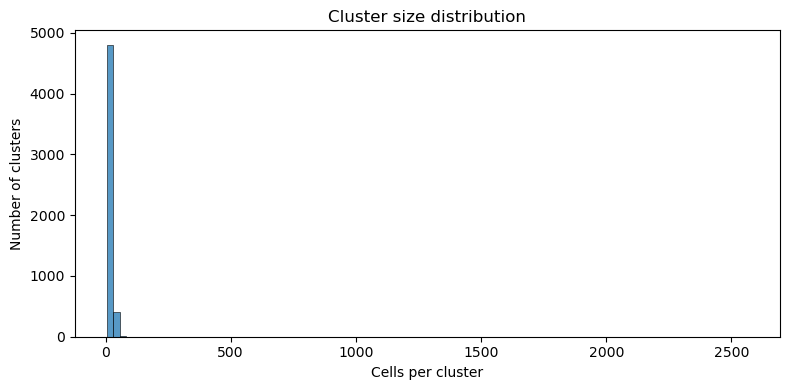

In [51]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 4))
sns.histplot(counts_df["count"], bins=100, kde=False)

plt.xlabel("Cells per cluster")
plt.ylabel("Number of clusters")
plt.title("Cluster size distribution")
plt.tight_layout()
plt.show()


# Closing Objects

In [52]:
peak_adata.close()
